# T01 · MACEField: electric-field switching

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Neutrino155/MACE_tutorials/blob/main/MACE_extensions/T01-MACEField.ipynb)

**Lennard-Jones Centre · University of Cambridge · Atomic-Scale Modelling**

Train a field-dependent interatomic model and follow a Ti soft mode as an electric field reverses direction.

**By the end, you can:**
- trace how MACEField adds the electric field to MACE;
- fit energy, force and polarization labels from one simple model;
- distinguish a field sweep with memory from the lowest-energy state at each field.

[Architecture recipe · T00](T00-Extending-MACE.ipynb) · [MACE Practice I](../MACE_in_practice_I/T01-MACE-Practice-I.ipynb) · [MACE Practice II](../MACE_in_practice_II/T02-MACE-Practice-II.ipynb) · [MACE Theory](../MACE_advanced/T03-MACE-Theory.ipynb)


## Setup

Run the cells in order. Use a CUDA runtime for faster fitting; the same cells also run on CPU. Local Jupyter finds `mace-field-develop` beside this repository or uses `MACEFIELD_ROOT` if you set it.


In [ ]:
# @title Find the repository and MACE-Field source
import warnings
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=DeprecationWarning)
_original_showwarning = warnings.showwarning

def _quiet_user_and_deprecation_warnings(message, category, filename, lineno,
                                         file=None, line=None):
    if issubclass(category, (UserWarning, DeprecationWarning)):
        return
    _original_showwarning(message, category, filename, lineno, file=file, line=line)

warnings.showwarning = _quiet_user_and_deprecation_warnings

import subprocess
import sys
from pathlib import Path

tutorial_root = next(
    (root.resolve() for root in (Path.cwd(), *Path.cwd().parents)
     if (root / "MACE_extensions").is_dir()),
    None,
)
if tutorial_root is None:
    if not Path("/content").is_dir():
        raise FileNotFoundError("Open this notebook from the MACE_tutorials repository.")
    tutorial_root = Path("/content/MACE_tutorials")
    if not (tutorial_root / "MACE_extensions").is_dir():
        subprocess.run(
            ["git", "clone", "--depth", "1", "--branch", "main",
             "https://github.com/Neutrino155/MACE_tutorials.git", str(tutorial_root)],
            check=True,
        )

sys.path.insert(0, str(tutorial_root))
from MACE_extensions.scripts.notebook_setup import setup

setup_paths = setup(feature="field")
asset_root = Path(setup_paths["asset_root"])
source_root = Path(setup_paths["source_root"])


In [ ]:
# @title Import the tools
import importlib
import json

import matplotlib.pyplot as plt
import numpy as np
import torch
from ase import Atoms
from ase.io import read
from IPython.display import display
from mace.calculators import MACECalculator
from mace.modules.extensions import MACEField

from MACE_extensions.scripts.prepare_teaching_data import (
    BTO_LANDAU_BARRIER as barrier_ev,
    BTO_MODE_CHARGE_Z as mode_charge,
    BTO_MODE_D0 as mode_d0,
    BTO_REFERENCE_CELL as reference_cell,
    BTO_REFERENCE_VOLUME as reference_volume,
    bto_enthalpy,
    bto_field_stationary_derivatives,
    bto_mode_dipole,
    bto_stationary_displacements,
)
from MACE_extensions.scripts.notebook_tools import (
    require_clean_source,
    run_python_script,
    show_source_hits,
    train_mace,
)
from MACE_extensions.scripts import structure_viewer
importlib.reload(structure_viewer)
show_structure = structure_viewer.show_structure
animate_structures = structure_viewer.animate_structures

device = "cuda" if torch.cuda.is_available() else "cpu"
torch.set_num_threads(1)
dtype = "float32"
field_head = "Default"
print(f"MACE-Field source: {source_root} · device: {device}")


## 1 · Add a field to the MACE energy model

MACEField passes the applied field into the equivariant message-passing stack. The model predicts a field-dependent scalar energy; forces and polarization follow from its derivatives.


![MACEField architecture with the electric-field pathway highlighted](figures/architecture_macefield.png)

The graph-level field vector is broadcast to atoms and combined with their equivariant features. The MACE interaction and product blocks still build the local representation; field-aware readout produces the energy surface used by the calculator.


### Trace the field pathway in the source

Find where the field features are defined, broadcast to atoms and used to compute polarization.


In [2]:
from mace.modules.utils import get_polarization

show_source_hits(
    MACEField.__init__,
    needles=("self.field_feats", "self.field_linear"),
    context=3,
)
show_source_hits(
    MACEField.forward,
    needles=("per_atom_electric_field =", "field_feat("),
    context=3,
)
show_source_hits(
    MACEField.forward,
    needles=("polarization = get_polarization(",),
    context=1,
)
show_source_hits(
    get_polarization,
    needles=("torch.autograd.grad(", "return -polarization"),
    context=2,
)


159 160 161 162 163 164 165 166 167 168 169 170 171 172,"cueq_config = kwargs.get(""cueq_config"", None) irreps_1o = o3.Irreps(""1o"") self.field_feats = torch.nn.ModuleList( FullyConnectedTensorProduct( irreps_in1=hidden_irreps, irreps_in2=irreps_1o, for _ in range(self.num_interactions - 1) ) self.field_linear = torch.nn.ModuleList( Linear( irreps_in=hidden_irreps, irreps_out=hidden_irreps,"


184 185 186 187 188 189 190 191 192 193 194 195 196 197,"node_feats_list: List[torch.Tensor] = [] # Precompute per-atom electric field once per_atom_electric_field = electric_field[data[""batch""].to(torch.long)] for i, (interaction, product) in enumerate( zip(self.interactions, self.products) zip(self.field_feats, self.field_linear) ): if i == j: delta_node_feats = field_feat( node_feats, per_atom_electric_field, )"


184 185 186,"# First derivative: P = -dE/dE_field polarization = get_polarization( energy=inter_e,"


779 780 781 782 783 784 785 786,"energy = energy[graph_mask] grad_outputs: List[Optional[torch.Tensor]] = [torch.ones_like(energy)] polarization = torch.autograd.grad( outputs=[energy], # [n_graphs, ...] inputs=[electric_field], # [n_graphs, 3] or [1, 3] # sign convention: P = -∂E/∂E_field return -polarization # [n_graphs, 3]"


<details>
<summary><b>Background theory · field, energy and polarization</b></summary>

For this fixed cell, the teaching model uses one coordinate: the Ti displacement $d$ along $z$. Its electric enthalpy is

$$
H(d,E_z)=B\left[\left(rac{d}{d_0}ight)^2-1ight]^2-E_z Z d.
$$

The first term has two minima at $d=\pm d_0$ and a barrier $B$. The second term is the coupling of the cell dipole $D_z=Zd$ to the field. Differentiating the same scalar gives the mode force and polarization density:

$$
F_{\mathrm{Ti},z}=-rac{\partial H}{\partial d},\qquad
P_z=-rac{1}{\Omega}rac{\partial H}{\partial E_z}=rac{Zd}{\Omega}.
$$

Here $d_0=0.12$ Å, $B=0.025$ eV per five-atom cell, $Z=5.8e$, and $\Omega=3.90	imes3.90	imes4.10$ Å$^3$. These are transparent teaching parameters, not a BaTiO$_3$ fit. The cell stays fixed throughout.

</details>


### See how the field tilts the double well

A field lowers the energy of the domain whose dipole points along it. Near the switching field, one local minimum disappears.


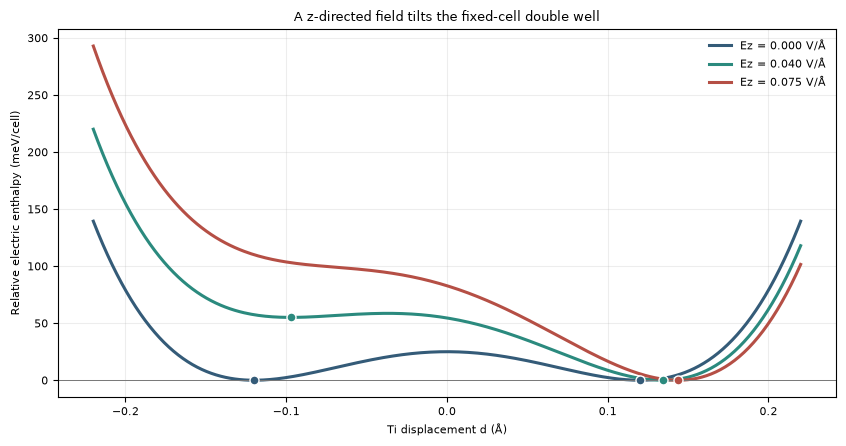

In [4]:
displacements = np.linspace(-0.22, 0.22, 301)
fig, ax = plt.subplots(figsize=(8.5, 4.5))
for ez, colour in ((0.0, "#345b78"), (0.04, "#2b8a7e"), (0.075, "#b54f45")):
    energies = np.array([bto_enthalpy(d, ez) for d in displacements])
    minima = bto_stationary_displacements(ez)
    ax.plot(displacements, (energies - energies.min()) * 1000,
            color=colour, lw=2.2, label=f"Ez = {ez:.3f} V/Å")
    ax.scatter(minima,
               [(bto_enthalpy(d, ez) - energies.min()) * 1000 for d in minima],
               color=colour, edgecolor="white", s=42, zorder=3)
ax.set(xlabel="Ti displacement d (Å)", ylabel="Relative electric enthalpy (meV/cell)",
       title="A z-directed field tilts the fixed-cell double well")
ax.axhline(0, color="#777777", lw=0.7)
ax.grid(alpha=0.22)
ax.legend(frameon=False)
fig.tight_layout()
plt.show()


## 2 · Inspect the five-atom switching cell

Only Ti moves in this model. The Ba and O positions and the cell vectors stay fixed.


In [5]:
# @title Inspect the structure
def bto_probe(displacement=0.0):
    fractional_positions = [
        [0.0, 0.0, 0.0],
        [0.5, 0.5, 0.5],
        [0.5, 0.5, 0.0],
        [0.5, 0.0, 0.5],
        [0.0, 0.5, 0.5],
    ]
    atoms = Atoms("BaTiO3", scaled_positions=fractional_positions,
                  cell=reference_cell, pbc=True)
    atoms.positions[1, 2] += float(displacement)
    return atoms

structure = bto_probe(mode_d0).repeat((2, 2, 2))
display(show_structure(structure, title="Fixed-cell BaTiO3-like switching motif"))


<IPython.core.display.Javascript object>

## 3 · The training labels

Each structure carries the applied field, electric enthalpy, atomic forces and polarization. Training and validation use different Ti displacements; the labels come from the same analytic energy surface.


In [6]:
train_frames = read(asset_root / "data/macefield_batio3_toy_train.extxyz", index=":")
valid_frames = read(asset_root / "data/macefield_batio3_toy_valid.extxyz", index=":")
print(f"train / validation structures: {len(train_frames)} / {len(valid_frames)}")
print("field range (V/Å):",
      min(a.info["REF_electric_field"][2] for a in train_frames), "to",
      max(a.info["REF_electric_field"][2] for a in train_frames))
print("fields are z-directed:", all(np.allclose(a.info["REF_electric_field"][:2], 0)
                                       for a in train_frames + valid_frames))
print("one cell throughout:", all(np.allclose(a.cell.array, reference_cell)
                                   for a in train_frames + valid_frames))
print("labels:", sorted(train_frames[0].info), sorted(train_frames[0].arrays))
print("label source:", train_frames[0].info["label_source"])


train / validation structures: 345 / 132
field range (V/Å): -0.12 to 0.12
fields are z-directed: True
one cell throughout: True
labels: ['REF_electric_field', 'REF_energy', 'REF_mode_displacement', 'REF_polarization', 'config_type', 'label_source'] ['REF_forces', 'numbers', 'positions']
label source: fixed-cell analytic Landau field-switching toy; not DFT or experiment


### Fit energy, forces and polarization

The shared scalar-energy loss fits the double well and its field tilt. Polarization supervision anchors the field derivative. This run trains from random initialization.


In [ ]:
# @title Train MACEField
source_revision = require_clean_source(source_root)
print("MACE-Field source revision:", source_revision)

run_dir = asset_root / "models" / "macefield_switching"
training_config = {
    "name": "MACEField-Landau",
    "model": "MACEField",
    "loss": "universal_field",
    "hidden_irreps": "16x0e + 16x1o",
    "num_interactions": 2,
    "r_max": 5.0,
    "train_file": str(asset_root / "data/macefield_batio3_toy_train.extxyz"),
    "valid_file": str(asset_root / "data/macefield_batio3_toy_valid.extxyz"),
    "valid_fraction": 0,
    "energy_key": "REF_energy",
    "forces_key": "REF_forces",
    "electric_field_key": "REF_electric_field",
    "polarization_key": "REF_polarization",
    "compute_forces": True,
    "compute_stress": False,
    "compute_polarization": True,
    "compute_becs": False,
    "compute_polarizability": False,
    "energy_weight": 1.0,
    "forces_weight": 100.0,
    "polarization_weight": 1.0,
    "stress_weight": 0.0,
    "E0s": {8: 0.0, 22: 0.0, 56: 0.0},
    "batch_size": 32,
    "valid_batch_size": 32,
    "max_num_epochs": 160,
    "eval_interval": 10,
    "default_dtype": dtype,
    "device": device,
    "seed": 23,
    "lr": 0.005,
    "freeze": 0,
    "model_dir": str(run_dir),
}
try:
    train_mace(training_config)
except subprocess.CalledProcessError:
    if device != "cuda":
        raise
    print("GPU training could not complete; retrying the fit on CPU.")
    device = "cpu"
    training_config["device"] = device
    run_dir = run_dir / "cpu_fallback"
    training_config["model_dir"] = str(run_dir)
    train_mace(training_config)

field_model_path = run_dir / "MACEField-Landau.model"
if not field_model_path.is_file():
    raise FileNotFoundError(f"Training did not produce {field_model_path}")
setup_paths["macefield_model"] = field_model_path

run_python_script(
    asset_root / "scripts/audit_macefield_surface.py",
    "--model", field_model_path,
    "--head", field_head,
    "--device", device,
    "--dtype", dtype,
    "--max-force-rmse-mev", "160.0",
    "--out", run_dir / "surface-audit",
    python_path=(tutorial_root, source_root),
)
audit = json.loads((run_dir / "surface-audit/macefield-audit.json").read_text())
print("Audit:", audit["status"])
print(f"Barrier: {audit['double_well']['central_barrier_meV_per_cell']:.2f} meV/cell · "
      f"Ti-force curve RMSE: {audit['double_well']['force_rmse_meV_per_A_on_scan_vs_analytic_target']:.1f} meV/Å")
print("Switching fields:", audit['switching_loop']['increasing_field_jump_V_per_A'],
      audit['switching_loop']['decreasing_field_jump_V_per_A'], "V/Å")


## 4 · Check the fitted double well

At zero field, the trained model should retain two minima near $\pm d_0$ and a positive barrier. Compare its energy and Ti force with the analytic target.


model minima (Å): [-0.12  0.12]
model barrier: 23.46 meV/cell


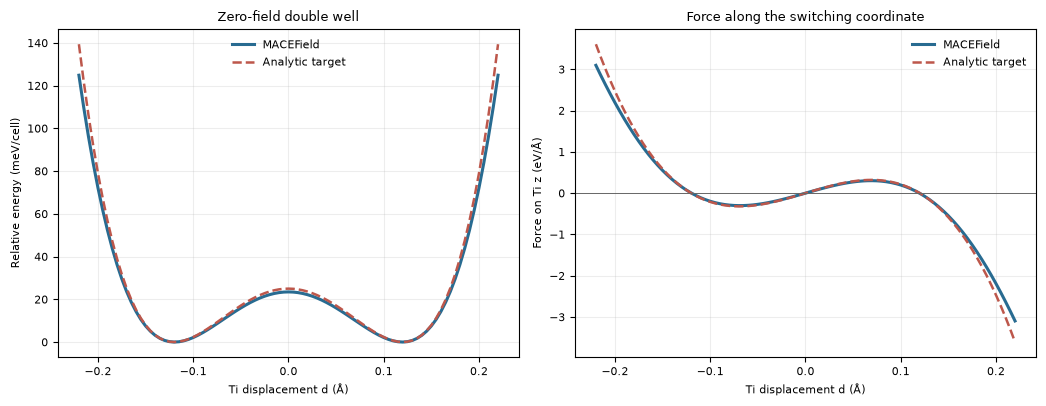

In [8]:
d_scan = np.linspace(-0.22, 0.22, 89)
zero_field_calc = MACECalculator(
    model_paths=str(field_model_path), model_type="MACEField", head=field_head,
    device=device, default_dtype=dtype,
    electric_field=[0.0, 0.0, 0.0],
    compute_polarization=False, compute_becs=False, compute_polarizability=False,
)
model_energy, model_force = [], []
for d in d_scan:
    atoms = bto_probe(d)
    atoms.calc = zero_field_calc
    model_energy.append(atoms.get_potential_energy())
    model_force.append(atoms.get_forces()[1, 2])
model_energy = np.asarray(model_energy)
model_force = np.asarray(model_force)
reference_energy = np.array([bto_enthalpy(d, 0.0) for d in d_scan])
reference_force = np.array([-bto_field_stationary_derivatives(d, 0.0)[0] for d in d_scan])
minima = np.where((model_energy[1:-1] < model_energy[:-2]) &
                  (model_energy[1:-1] < model_energy[2:]))[0] + 1
barrier = (model_energy[np.argmin(np.abs(d_scan))] - model_energy[minima].mean()) * 1000
print("model minima (Å):", np.round(d_scan[minima], 3))
print(f"model barrier: {barrier:.2f} meV/cell")

fig, axes = plt.subplots(1, 2, figsize=(10.5, 4.1))
axes[0].plot(d_scan, (model_energy - model_energy.min()) * 1000,
             color="#286b91", lw=2.2, label="MACEField")
axes[0].plot(d_scan, reference_energy * 1000, "--",
             color="#bd574b", lw=1.8, label="Analytic target")
axes[0].set(xlabel="Ti displacement d (Å)", ylabel="Relative energy (meV/cell)",
            title="Zero-field double well")
axes[1].plot(d_scan, model_force, color="#286b91", lw=2.2, label="MACEField")
axes[1].plot(d_scan, reference_force, "--",
             color="#bd574b", lw=1.8, label="Analytic target")
axes[1].axhline(0, color="#666666", lw=0.7)
axes[1].set(xlabel="Ti displacement d (Å)", ylabel="Force on Ti z (eV/Å)",
            title="Force along the switching coordinate")
for ax in axes:
    ax.grid(alpha=0.22)
    ax.legend(frameon=False)
fig.tight_layout()
plt.show()


### Check polarization from the field derivative

At fixed geometry, compare the model's polarization with the finite-difference slope of its energy.


maximum |Pz − finite-difference Pz| (e/Å²): 5.05343356044588e-07


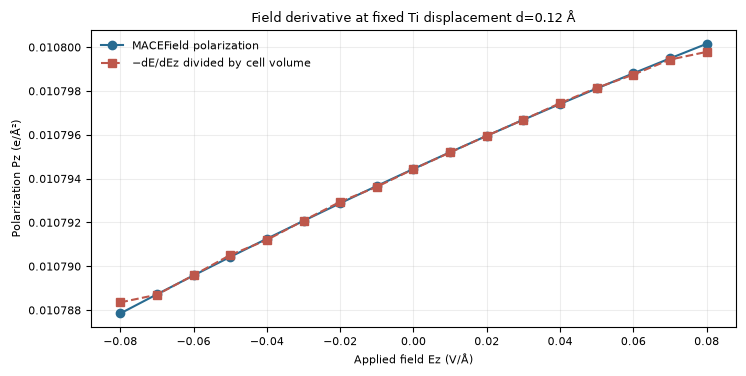

In [9]:
field_values = np.linspace(-0.08, 0.08, 17)
probe = bto_probe(mode_d0)
field_energies, field_pz = [], []
for ez in field_values:
    probe.calc = MACECalculator(
        model_paths=str(field_model_path), model_type="MACEField", head=field_head,
        device=device, default_dtype=dtype,
        electric_field=[0.0, 0.0, float(ez)],
        compute_polarization=True, compute_becs=False, compute_polarizability=False,
    )
    field_energies.append(probe.get_potential_energy())
    field_pz.append(float(probe.calc.results["polarization"][2]))
field_energies = np.asarray(field_energies)
field_pz = np.asarray(field_pz)
finite_difference_pz = -np.gradient(field_energies, field_values) / reference_volume
print("maximum |Pz − finite-difference Pz| (e/Å²):",
      float(np.max(np.abs(field_pz - finite_difference_pz))))

fig, ax = plt.subplots(figsize=(7.5, 3.8))
ax.plot(field_values, field_pz, "o-", color="#286b91", label="MACEField polarization")
ax.plot(field_values, finite_difference_pz, "s--", color="#bd574b",
        label="−dE/dEz divided by cell volume")
ax.set(xlabel="Applied field Ez (V/Å)", ylabel="Polarization Pz (e/Å²)",
       title=f"Field derivative at fixed Ti displacement d={mode_d0:.2f} Å")
ax.grid(alpha=0.22)
ax.legend(frameon=False)
fig.tight_layout()
plt.show()


## 5 · Follow the electric-field switching loop

For a quasi-static field sweep, carry each local minimum forward from the previous field value. When that minimum loses stability, the soft mode switches to the other well. Minimizing independently at every field instead gives the lowest-energy branch and removes the hysteresis.


analytic switching fields: -0.0553, +0.0553 V/Å


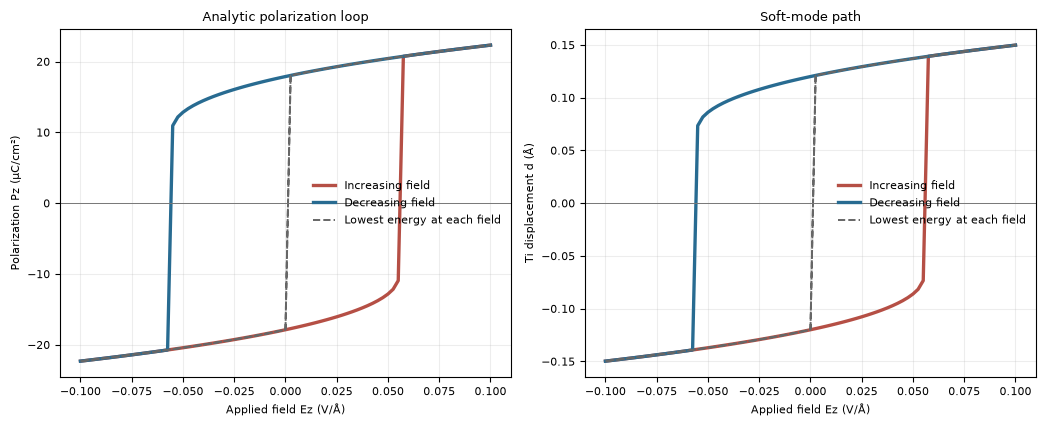

In [10]:
fields_up = np.linspace(-0.10, 0.10, 81)
field_cycle = np.concatenate([fields_up, fields_up[-2::-1]])
n_up = len(fields_up)

def follow_analytic_branch(fields, initial_displacement):
    previous = float(initial_displacement)
    branch = []
    for ez in fields:
        minima = bto_stationary_displacements(float(ez))
        if not minima:
            raise RuntimeError(f"No stable mode at Ez={ez:+.4f} V/Å")
        previous = min(minima, key=lambda value: abs(value - previous))
        branch.append(previous)
    return np.asarray(branch)

reference_d = np.concatenate([
    follow_analytic_branch(fields_up, -mode_d0),
    follow_analytic_branch(fields_up[-2::-1], mode_d0),
])
reference_p = np.array([bto_mode_dipole(d) / reference_volume for d in reference_d])
equilibrium_d = np.array([
    min(bto_stationary_displacements(float(ez)),
        key=lambda d: bto_enthalpy(d, float(ez)))
    for ez in field_cycle
])
equilibrium_p = np.array([bto_mode_dipole(d) / reference_volume for d in equilibrium_d])
spinodal_d = mode_d0 / np.sqrt(3.0)
spinodal_field = bto_field_stationary_derivatives(-spinodal_d, 0.0)[0] / mode_charge
print(f"analytic switching fields: {-spinodal_field:+.4f}, {spinodal_field:+.4f} V/Å")

fig, axes = plt.subplots(1, 2, figsize=(10.5, 4.3))
for ax, values, ylabel, title in (
    (axes[0], reference_p * 1602.176634, "Polarization Pz (µC/cm²)", "Analytic polarization loop"),
    (axes[1], reference_d, "Ti displacement d (Å)", "Soft-mode path"),
):
    ax.plot(field_cycle[:n_up], values[:n_up], color="#b54f45", lw=2.4,
            label="Increasing field")
    ax.plot(field_cycle[n_up - 1:], values[n_up - 1:], color="#286b91", lw=2.4,
            label="Decreasing field")
    equilibrium = equilibrium_p * 1602.176634 if ax is axes[0] else equilibrium_d
    ax.plot(field_cycle, equilibrium, "--", color="#666666", lw=1.4,
            label="Lowest energy at each field")
    ax.set(xlabel="Applied field Ez (V/Å)", ylabel=ylabel, title=title)
    ax.axhline(0, color="#777777", lw=0.7)
    ax.grid(alpha=0.22)
    ax.legend(frameon=False, fontsize=8)
fig.tight_layout()
plt.show()


### Compare the trained MACEField model

The root-following calculation relaxes only Ti along $z$; it keeps the cell and all other atoms fixed. The field range stays inside the training data.


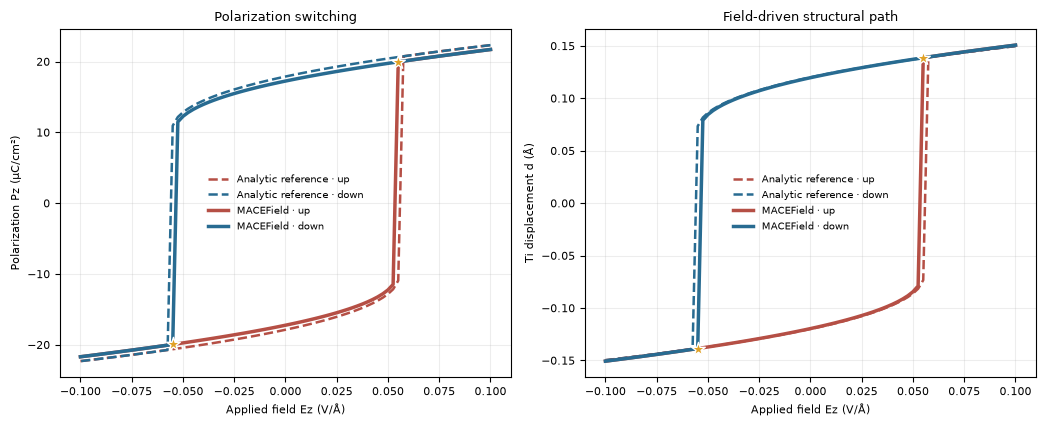

MACEField switching fields: +0.0550, -0.0550 V/Å
Remanent polarization gap: 34.49 µC/cm²
Full-cycle polarization RMSE: 3.50 µC/cm²
Relaxed steps: 161 of 161


In [11]:
from MACE_extensions.scripts.audit_macefield_surface import nearest_stable_mode_root

model_fields_up = np.linspace(-0.10, 0.10, 81)
model_field_cycle = np.concatenate([model_fields_up, model_fields_up[-2::-1]])
model_d, model_p, model_states = [], [], []
root_calc = MACECalculator(
    model_paths=str(field_model_path), model_type="MACEField", head=field_head,
    device=device, default_dtype=dtype,
    electric_field=[0.0, 0.0, float(model_field_cycle[0])],
    compute_forces=True, compute_polarization=False,
    compute_becs=False, compute_polarizability=False,
)
loop_calc = MACECalculator(
    model_paths=str(field_model_path), model_type="MACEField", head=field_head,
    device=device, default_dtype=dtype,
    electric_field=[0.0, 0.0, float(model_field_cycle[0])],
    compute_forces=True, compute_polarization=True,
    compute_becs=False, compute_polarizability=False,
)
relaxed_d = -mode_d0
for ez in model_field_cycle:
    root_calc.electric_field = [0.0, 0.0, float(ez)]
    root_calc.reset()
    relaxed_d = nearest_stable_mode_root(root_calc, relaxed_d, bounds=(-0.22, 0.22))
    loop_calc.electric_field = [0.0, 0.0, float(ez)]
    loop_calc.reset()
    atoms = bto_probe(relaxed_d)
    atoms.calc = loop_calc
    atoms.get_potential_energy()
    model_d.append(float(relaxed_d))
    model_p.append(float(loop_calc.results["polarization"][2]))
    model_states.append(atoms.copy())
model_d = np.asarray(model_d)
model_p = np.asarray(model_p)
up_jump = int(np.argmax(np.abs(np.diff(model_d[:n_up]))) + 1)
down_jump = int(np.argmax(np.abs(np.diff(model_d[n_up - 1:]))) + n_up)
zero_up = int(np.argmin(np.abs(model_field_cycle[:n_up])))
zero_down = n_up - 1 + int(np.argmin(np.abs(model_field_cycle[n_up - 1:])))
remanent_gap = abs(model_p[zero_down] - model_p[zero_up])
loop_rmse = np.sqrt(np.mean((model_p - reference_p) ** 2)) * 1602.176634

fig, axes = plt.subplots(1, 2, figsize=(10.5, 4.3))
axes[0].plot(field_cycle[:n_up], reference_p[:n_up] * 1602.176634,
             "--", color="#b54f45", lw=1.8, label="Analytic reference · up")
axes[0].plot(field_cycle[n_up - 1:], reference_p[n_up - 1:] * 1602.176634,
             "--", color="#286b91", lw=1.8, label="Analytic reference · down")
axes[0].plot(model_field_cycle[:n_up], model_p[:n_up] * 1602.176634,
             color="#b54f45", lw=2.5, label="MACEField · up")
axes[0].plot(model_field_cycle[n_up - 1:], model_p[n_up - 1:] * 1602.176634,
             color="#286b91", lw=2.5, label="MACEField · down")
axes[0].scatter(model_field_cycle[[up_jump, down_jump]],
                model_p[[up_jump, down_jump]] * 1602.176634,
                marker="*", s=105, color="#e0a126", edgecolor="white", zorder=4)
axes[0].set(xlabel="Applied field Ez (V/Å)", ylabel="Polarization Pz (µC/cm²)",
            title="Polarization switching")
axes[1].plot(field_cycle[:n_up], reference_d[:n_up], "--",
             color="#b54f45", lw=1.8, label="Analytic reference · up")
axes[1].plot(field_cycle[n_up - 1:], reference_d[n_up - 1:], "--",
             color="#286b91", lw=1.8, label="Analytic reference · down")
axes[1].plot(model_field_cycle[:n_up], model_d[:n_up],
             color="#b54f45", lw=2.5, label="MACEField · up")
axes[1].plot(model_field_cycle[n_up - 1:], model_d[n_up - 1:],
             color="#286b91", lw=2.5, label="MACEField · down")
axes[1].scatter(model_field_cycle[[up_jump, down_jump]], model_d[[up_jump, down_jump]],
                marker="*", s=105, color="#e0a126", edgecolor="white", zorder=4)
axes[1].set(xlabel="Applied field Ez (V/Å)", ylabel="Ti displacement d (Å)",
            title="Field-driven structural path")
for ax in axes:
    ax.grid(alpha=0.22)
    ax.legend(frameon=False, fontsize=7.5)
fig.tight_layout()
plt.show()
print(f"MACEField switching fields: {model_field_cycle[up_jump]:+.4f}, "
      f"{model_field_cycle[down_jump]:+.4f} V/Å")
print(f"Remanent polarization gap: {remanent_gap * 1602.176634:.2f} µC/cm²")
print(f"Full-cycle polarization RMSE: {loop_rmse:.2f} µC/cm²")
print("Relaxed steps:", len(model_states), "of", len(model_field_cycle))
if not (model_field_cycle[up_jump] > 0 and model_field_cycle[down_jump] < 0
        and remanent_gap > 1e-3):
    raise RuntimeError("The fitted model did not show a path-dependent switching loop.")


### Watch the field-driven structure

Scrub the field cycle to follow the Ti displacement and polarization. The repeated cell is for visibility; the calculation uses one primitive cell.


In [12]:
# @title Animate the switching path
frame_indices = list(range(0, len(model_states), 3))
if frame_indices[-1] != len(model_states) - 1:
    frame_indices.append(len(model_states) - 1)
visual_states = [model_states[i].repeat((2, 2, 2)) for i in frame_indices]
visual_vectors = [
    [{"origin": state.get_center_of_mass(),
      "vector": [0.0, 0.0, model_p[i]],
      "label": "P", "units": "e Å⁻²", "color": "#13849a", "length": 1.6}]
    for i, state in zip(frame_indices, visual_states)
]
frame_labels = [
    f"Ez={model_field_cycle[i]:+.3f} V/Å · d={model_d[i]:+.3f} Å · "
    f"Pz={model_p[i] * 1602.176634:+.1f} µC/cm²"
    for i in frame_indices
]
display(animate_structures(
    visual_states,
    title="Ti displacement during field switching",
    frame_labels=frame_labels,
    vectors_by_frame=visual_vectors,
    show_cell=True,
))


<IPython.core.display.Javascript object>

## Acknowledgements

This extension was prepared by **Bradley Martin**. The architecture figure is adapted from the [MACE Theory notebook](../MACE_advanced/T03-MACE-Theory.ipynb); see [figure attribution](figures/ATTRIBUTION.md). The [Practice I](../MACE_in_practice_I/T01-MACE-Practice-I.ipynb), [Practice II](../MACE_in_practice_II/T02-MACE-Practice-II.ipynb), [advanced application examples](../MACE_advanced/), and MACE Theory notebooks were created by **Ioan Magdău, Ilyes Batatia and Will Baldwin**, and further refined by **Ioan Magdău and Alin Elena**.
